In [72]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler

In [73]:
train_df = pd.read_csv("customer_train.csv")
test_df = pd.read_csv("customer_test.csv")

train_df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [74]:
train_df.info()
train_df.describe()
train_df.nunique()

<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 40.4 MB


CustomerID           440832
Age                      48
Gender                    2
Tenure                   60
Usage Frequency          30
Support Calls            11
Payment Delay            31
Subscription Type         3
Contract Length           3
Total Spend           68363
Last Interaction         30
Churn                     2
dtype: int64

In [75]:
cat_cols = train_df.select_dtypes(include='object').columns
print(cat_cols)

Index(['Gender', 'Subscription Type', 'Contract Length'], dtype='str')


C:\Users\user\AppData\Local\Temp\ipykernel_17392\1617834087.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train_df.select_dtypes(include='object').columns


In [76]:
print(train_df.columns)

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='str')


In [77]:
train_df['Gender']

0         Female
1         Female
2         Female
3           Male
4           Male
           ...  
440828      Male
440829    Female
440830      Male
440831      Male
440832      Male
Name: Gender, Length: 440833, dtype: str

In [78]:
le = LabelEncoder()

train_df['Gender'] = le.fit_transform(train_df['Gender'])

In [79]:
train_df = pd.get_dummies(train_df, drop_first=True)

In [80]:
print(train_df.columns.tolist())

['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn', 'Subscription Type_Premium', 'Subscription Type_Standard', 'Contract Length_Monthly', 'Contract Length_Quarterly']


In [81]:
train_df.columns = train_df.columns.str.strip()

In [82]:
print(train_df.columns.tolist())
train_df.columns = train_df.columns.str.strip()
print(train_df.columns.tolist())

['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn', 'Subscription Type_Premium', 'Subscription Type_Standard', 'Contract Length_Monthly', 'Contract Length_Quarterly']
['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn', 'Subscription Type_Premium', 'Subscription Type_Standard', 'Contract Length_Monthly', 'Contract Length_Quarterly']


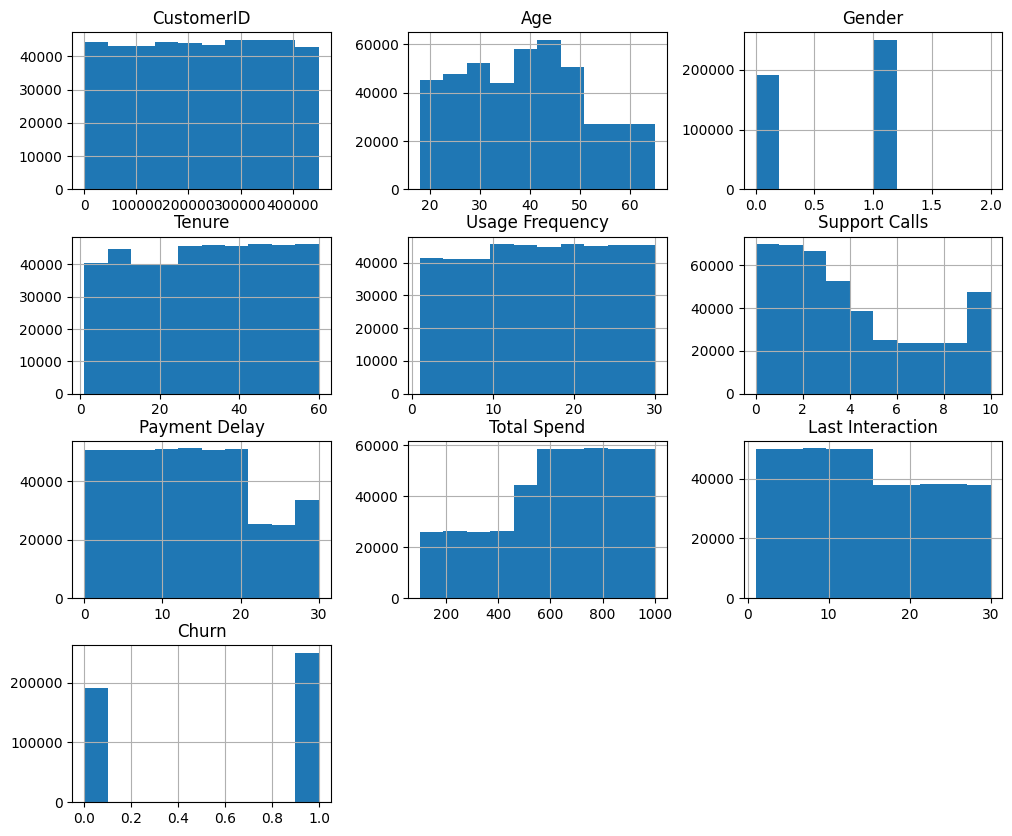

In [83]:
train_df.hist(figsize=(12,10))
plt.show()

In [84]:
scaler = StandardScaler()

num_cols = train_df.select_dtypes(include=np.number).columns

train_df[num_cols] = scaler.fit_transform(train_df[num_cols])

In [85]:
scaler = MinMaxScaler()

train_df[num_cols] = scaler.fit_transform(train_df[num_cols])

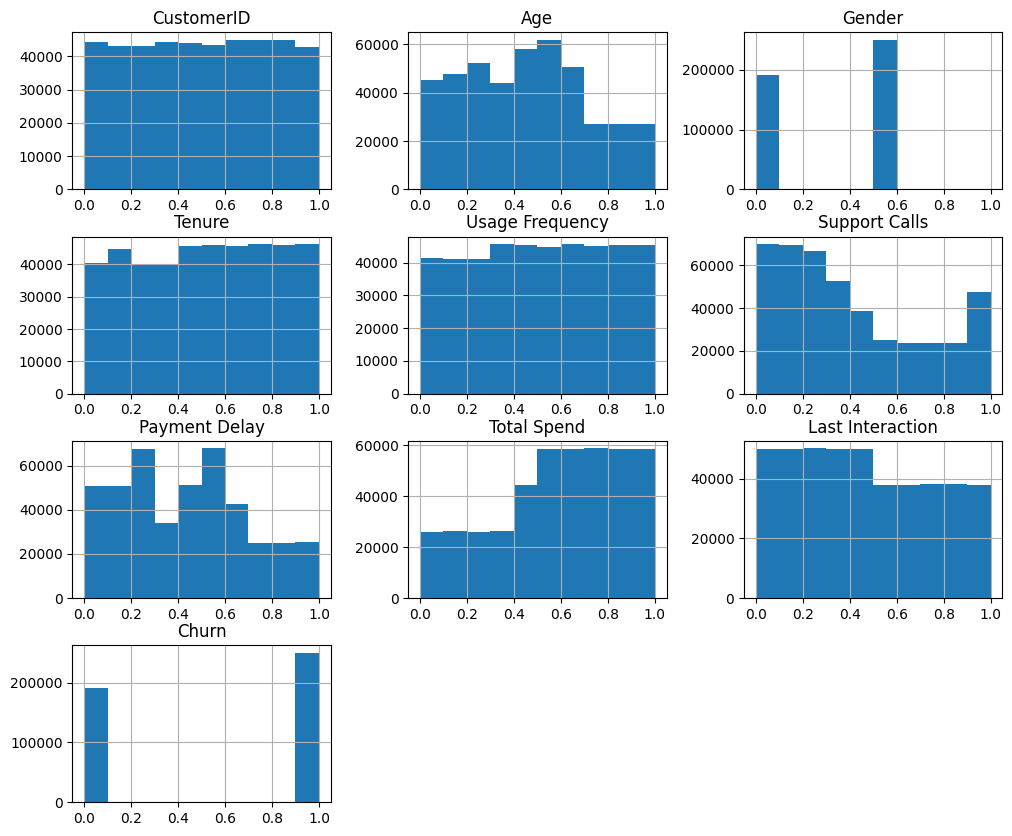

In [86]:
train_df.hist(figsize=(12,10))
plt.show()

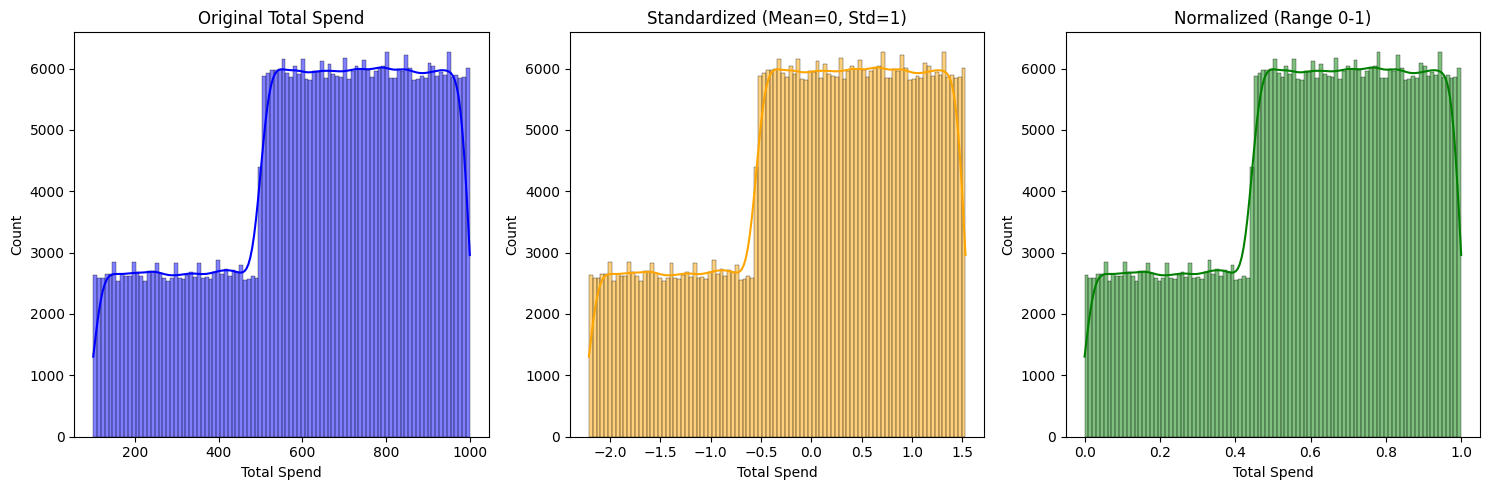

Preprocessed Data Preview:
    Age  Tenure  Usage Frequency  Support Calls  Payment Delay  \
0  30.0    39.0             14.0            5.0           18.0   
1  65.0    49.0              1.0           10.0            8.0   
2  55.0    14.0              4.0            6.0           18.0   
3  58.0    38.0             21.0            7.0            7.0   
4  23.0    32.0             20.0            5.0            8.0   

   Subscription Type  Contract Length  Total Spend  Last Interaction  Churn  \
0                  1                2        932.0              17.0    1.0   
1                  0                0        557.0               6.0    1.0   
2                  0                1        185.0               3.0    1.0   
3                  1                0        396.0              29.0    1.0   
4                  0                0        617.0              20.0    1.0   

   Gender_Male  
0        False  
1        False  
2        False  
3         True  
4         True  

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 1. Load the Dataset
df = pd.read_csv('customer_train.csv')

# Drop irrelevant unique identifiers and missing values
df.drop('CustomerID', axis=1, inplace=True, errors='ignore')
df.dropna(inplace=True)

# 2. ENCODING CATEGORICAL VARIABLES

# Ordinal Encoding: Preserving order for Subscription and Contract
sub_map = {'Basic': 0, 'Standard': 1, 'Premium': 2}
contract_map = {'Monthly': 0, 'Quarterly': 1, 'Annual': 2}

df['Subscription Type'] = df['Subscription Type'].map(sub_map)
df['Contract Length'] = df['Contract Length'].map(contract_map)

# Nominal Encoding: One-Hot Encoding for Gender
# drop_first=True avoids the Dummy Variable Trap
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)

# 3. FEATURE SCALING

# Select numerical columns for comparison
num_cols = ['Age', 'Total Spend', 'Tenure']
data_to_scale = df[num_cols]

# Apply Standardization
std_scaler = StandardScaler()
df_std = pd.DataFrame(std_scaler.fit_transform(data_to_scale), columns=num_cols)

# Apply Normalization
mm_scaler = MinMaxScaler()
df_norm = pd.DataFrame(mm_scaler.fit_transform(data_to_scale), columns=num_cols)

# 4. VISUALIZING DISTRIBUTIONS
plt.figure(figsize=(15, 5))

# Plotting 'Total Spend' distribution comparison
plt.subplot(1, 3, 1)
sns.histplot(df['Total Spend'], kde=True, color='blue')
plt.title('Original Total Spend')

plt.subplot(1, 3, 2)
sns.histplot(df_std['Total Spend'], kde=True, color='orange')
plt.title('Standardized (Mean=0, Std=1)')

plt.subplot(1, 3, 3)
sns.histplot(df_norm['Total Spend'], kde=True, color='green')
plt.title('Normalized (Range 0-1)')

plt.tight_layout()
plt.show()

# Final Check
print("Preprocessed Data Preview:")
print(df.head())